# Jogo PCP 2 — FLAMENGO — Cockpit V3 (Rodada 3)

**Objetivo do solver V3:** maximizar serviço (entrega PA no dia EXATO) e minimizar custo, sabendo que:
- PA fora do dia solicitado é descartado (antes ou depois)
- PA tem que SAIR da F1 no mesmo dia em que é produzido
- MP que chega na F1 sem espaço é descartada
- Cap 220 transportes/semana

**Contexto R3:** 25 OPs PA3 totalizando 1.343.693 frascos, preço R$ 32. Próxima rodada (R4) será PA2 → produzimos buffer PA2 para pré-estocar no CD Santos.

**Fluxo:**
1. Setup + leitura instalações
2. Estado inicial (estoques MP + CDs zerados, vindos do PDF R3)
3. OPs R3 (todas PA3, do `RODADA_03_PA3.pdf`)
4. MP em trânsito chegando (sobras dos pedidos de R2)
5. Forecast HW R4 → dimensiona buffer PA2
6. Análise de viabilidade prévia (quais OPs cabem na janela)
7. Solver V3 — entrega exata + custo mínimo
8. Inspeção das tabelas SOL_TRANSP e OP_FABRICAS
9. Validação (cada OP atendida chega no dia certo?)
10. DRE / Indicadores / VPL
11. Gravar FLAMENGO.xlsm
12. Dashboard histórico

## 1. Setup

In [1]:
import sys, os, math
from pathlib import Path
import pandas as pd
BASE = Path('..').resolve()
sys.path.insert(0, str(BASE))
os.chdir(BASE)
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')
from src.config import Config
from src.io_xlsm import ler_instalacoes, escrever_planos_de_df
from src.planner_v3 import planejar_v3, todas_rotas_op, lead_dias
from src.planner_manual import forecast_proxima_rodada_via_hw
from src.indicadores import calcular_dre_e_ind, imprimir_painel
from src.dashboard import plot_historico
cfg = Config.load(BASE)
RODADA = 3
FLAMENGO_PATH = BASE / 'rodadas' / 'rodada_3' / 'FLAMENGO.xlsm'
instalacoes = ler_instalacoes(FLAMENGO_PATH)
print('OK — base:', BASE)
print('Rodada:', RODADA)
print('F1:', instalacoes['fabricas']['F1'])
print('CDs:', {cd: d['cidade'] for cd,d in instalacoes['cds'].items()})

OK — base: C:\Users\lolil\Downloads\Jogo PCP 2 (a vinganca)
Rodada: 3
F1: {'cidade': 'Joinville', 'maquinas': 7, 'turnos': 3, 'mo': 21, 'area_mp': {'MP1': 127.0, 'MP2': 36.0, 'MP3': 42.0}}
CDs: {'CD1': 'São Luís', 'CD2': 'Santos'}


## 2. Estado inicial — fim da R2 (do `ESTOQUES_FLAMENGO.pdf` da R3)

Estoque MP em F1 (Joinville) no dia 10 absoluto (fim da R2). CDs zerados — toda PA1 da R2 foi entregue.

In [2]:
ESTOQUE_MP = {'MP1': 78.98, 'MP2': 50.36, 'MP3': 48.14}
ESTOQUE_PA_CD = {cd: {'PA1': 0, 'PA2': 0, 'PA3': 0} for cd in instalacoes['cds']}
# Capacidades MP (área × pé_direito × densidade)
cap_mp = {mp: instalacoes['fabricas']['F1']['area_mp'][mp]
              * cfg.capacidades['pe_direito_deposito_m']
              * cfg.densidades_mp[mp]
          for mp in ('MP1','MP2','MP3')}
print('Estoque MP F1 (Joinville):')
for mp in ('MP1','MP2','MP3'):
    pct = ESTOQUE_MP[mp]/cap_mp[mp]*100
    print(f'  {mp}: {ESTOQUE_MP[mp]:>6.2f} / {cap_mp[mp]:>6.2f} ton ({pct:.1f}% ocup.)')
print('CDs zerados (toda R2 enviada aos varejistas)')

Estoque MP F1 (Joinville):
  MP1:  78.98 / 127.00 ton (62.2% ocup.)
  MP2:  50.36 /  50.40 ton (99.9% ocup.)
  MP3:  48.14 /  75.60 ton (63.7% ocup.)
CDs zerados (toda R2 enviada aos varejistas)


## 3. OPs do prof — Rodada 3 (do `RODADA_03_PA3.pdf`)

25 OPs, todas PA3, totalizando 1.343.693 frascos. Dias relativos à rodada (1-5).

In [3]:
OPS = [
    {'cidade': 'Belém',                'pa':'PA3','qtd':20155, 'dia_entrega':5},
    {'cidade': 'Belo Horizonte',       'pa':'PA3','qtd':70544, 'dia_entrega':3},
    {'cidade': 'Brasília',             'pa':'PA3','qtd':117573,'dia_entrega':3},
    {'cidade': 'Campinas',             'pa':'PA3','qtd':56435, 'dia_entrega':2},
    {'cidade': 'Campo Grande',         'pa':'PA3','qtd':23515, 'dia_entrega':3},
    {'cidade': 'Cuiabá',               'pa':'PA3','qtd':28218, 'dia_entrega':3},
    {'cidade': 'Curitiba',             'pa':'PA3','qtd':103464,'dia_entrega':2},
    {'cidade': 'Fortaleza',            'pa':'PA3','qtd':68528, 'dia_entrega':5},
    {'cidade': 'Goiânia',              'pa':'PA3','qtd':65841, 'dia_entrega':3},
    {'cidade': 'João Pessoa',          'pa':'PA3','qtd':40311, 'dia_entrega':4},
    {'cidade': 'Joinville',            'pa':'PA3','qtd':28218, 'dia_entrega':2},
    {'cidade': 'Maceió',               'pa':'PA3','qtd':40311, 'dia_entrega':4},
    {'cidade': 'Manaus',               'pa':'PA3','qtd':20155, 'dia_entrega':5},
    {'cidade': 'Natal',                'pa':'PA3','qtd':40311, 'dia_entrega':5},
    {'cidade': 'Porto Alegre',         'pa':'PA3','qtd':103464,'dia_entrega':2},
    {'cidade': 'Recife',               'pa':'PA3','qtd':60466, 'dia_entrega':4},
    {'cidade': 'Ribeirão Preto',       'pa':'PA3','qtd':47029, 'dia_entrega':2},
    {'cidade': 'Rio de Janeiro',       'pa':'PA3','qtd':94059, 'dia_entrega':3},
    {'cidade': 'Salvador',             'pa':'PA3','qtd':80622, 'dia_entrega':4},
    {'cidade': 'Santos',               'pa':'PA3','qtd':47029, 'dia_entrega':2},
    {'cidade': 'São Luís',             'pa':'PA3','qtd':20155, 'dia_entrega':5},
    {'cidade': 'São Paulo',            'pa':'PA3','qtd':117573,'dia_entrega':2},
    {'cidade': 'Uberlândia',           'pa':'PA3','qtd':23515, 'dia_entrega':3},
    {'cidade': 'Vitória',              'pa':'PA3','qtd':14109, 'dia_entrega':3},
    {'cidade': 'Vitória da Conquista', 'pa':'PA3','qtd':12093, 'dia_entrega':4},
]
total = sum(o['qtd'] for o in OPS)
print(f'{len(OPS)} OPs PA3 — total {total:,} frascos')
from collections import Counter
qtd_dia = Counter()
for o in OPS: qtd_dia[o['dia_entrega']] += o['qtd']
for d in sorted(qtd_dia):
    print(f'  Dia {d}: {qtd_dia[d]:>10,}')

25 OPs PA3 — total 1,343,693 frascos
  Dia 2:    503,212
  Dia 3:    437,374
  Dia 4:    233,803
  Dia 5:    169,304


## 4. MP em trânsito chegando na rodada

Pedidos de MP feitos em R2 que ainda estão a caminho da F1. Vêm do `SOL_TRANSP` da R2 (em `rodadas/FLAMENGO_envio.xlsm`).
Cálculo: data de coleta + lead caminhão. Só listamos os que chegam DURANTE R3 (dias 1-5).

In [4]:
import openpyxl, re
_DIA = re.compile(r'Dia\s*(\d+)')
_ROD = re.compile(r'Rodada_(\d+)')

def carregar_mp_em_transito_r3(envio_path: Path) -> list:
    """Lê SOL_TRANSP de R2 e retorna MP que chega nos dias 1-5 da R3.

    O escritor de plano grava o dia em formato ABSOLUTO do jogo (R2 = dias 6-10).
    Detecta isso: se dia > 5 já é absoluto; senão relativo à R2.
    """
    wb = openpyxl.load_workbook(envio_path, keep_vba=True, data_only=True)
    ws = wb['SOL_TRANSP']
    chegando = []
    for r in range(5, ws.max_row+1):
        val = ws.cell(r,1).value
        if not val: continue
        m = _ROD.search(str(val))
        if not m or int(m.group(1)) != 2: continue
        if (ws.cell(r,2).value or '').strip() != 'Fornecedor': continue
        origem = ws.cell(r,3).value
        dia_part_str = str(ws.cell(r,4).value)
        m2 = _DIA.search(dia_part_str)
        if not m2: continue
        dia_raw = int(m2.group(1))
        # Se > 5 já é absoluto; senão relativo à R2 (converte p/ absoluto)
        dia_abs_part = dia_raw if dia_raw > 5 else (2-1)*5 + dia_raw
        modal = ws.cell(r,5).value
        item = ws.cell(r,6).value
        qtd = float(ws.cell(r,7).value or 0)
        lt = lead_dias(cfg, origem, instalacoes['fabricas']['F1']['cidade'], modal)
        if lt is None: continue
        dia_abs_cheg = dia_abs_part + lt
        dia_rel_r3 = dia_abs_cheg - (RODADA-1)*5
        if 1 <= dia_rel_r3 <= 5:
            chegando.append({'dia': dia_rel_r3, 'mp': item, 'qtd': qtd,
                             'origem': origem, 'modal': modal, 'lt': lt})
    return chegando

MP_EM_TRANSITO = carregar_mp_em_transito_r3(BASE / 'rodadas' / 'FLAMENGO_envio.xlsm')
print(f'{len(MP_EM_TRANSITO)} MPs chegando durante R3:')
for x in MP_EM_TRANSITO:
    print(f'  Dia {x["dia"]}: {x["qtd"]:>5.1f} t {x["mp"]} de {x["origem"]} ({x["modal"]}, lt={x["lt"]}d)')

1 MPs chegando durante R3:
  Dia 1:   8.7 t MP1 de Manaus (Caminhão, lt=3d)


## 5. Forecast HW da R4 → dimensiona buffer PA2

In [5]:
forecast_r4 = forecast_proxima_rodada_via_hw(rodada_n_atual=RODADA, base_dir=BASE)
fc_pa_brasil = {'PA1': 0.0, 'PA2': 0.0, 'PA3': 0.0}
for (c, pa), v in forecast_r4.items():
    fc_pa_brasil[pa] += v
SHARE = 0.40  # Flamengo ~40% do mercado
fc_pa_flamengo = {pa: v*SHARE for pa, v in fc_pa_brasil.items()}
print('Forecast Brasil R4 → Flamengo (share 40%):')
for pa, v in fc_pa_flamengo.items():
    print(f'  {pa}: {v:>10,.0f} (brasil {fc_pa_brasil[pa]:>10,.0f})')
print()
# CAP CD2 Santos PA2 = 400.000 frascos (área × pé_direito × densidade)
# Buffer máximo viável = min(forecast, cap CD2 PA2)
cd_santos_cap_pa2 = int(instalacoes['cds']['CD2']['area_pa']['PA2']
                         * cfg.capacidades['pe_direito_deposito_m']
                         * cfg.densidades_pa['PA2']
                         / cfg.peso_un_ton['PA2'])
forecast_pa2_int = int(fc_pa_flamengo['PA2'])
BUFFER_PA2_R4 = min(forecast_pa2_int, cd_santos_cap_pa2)
print(f'Cap CD2 PA2: {cd_santos_cap_pa2:,} frascos')
print(f'Forecast R4 PA2 (Flamengo): {forecast_pa2_int:,}')
print(f'Buffer PA2 R3 = min(forecast, cap CD2 PA2) = {BUFFER_PA2_R4:,} frascos')
if BUFFER_PA2_R4 < forecast_pa2_int:
    print(f'  ⚠️ Buffer limitado pela capacidade do CD ({forecast_pa2_int-BUFFER_PA2_R4:,} frascos a menos)')
# Comprar tb MP pra começo de R4 (24 t MP1 + 24 t MP3 = 1 caminhão cada)
COMPRAS_MP_R4 = {'MP1': 24.0, 'MP3': 24.0}
print(f'MP extra pra R4 (1 cam cada): {COMPRAS_MP_R4}')

Forecast Brasil R4 → Flamengo (share 40%):
  PA1:    185,621 (brasil    464,053)
  PA2:    560,438 (brasil  1,401,096)
  PA3:    856,117 (brasil  2,140,293)

Cap CD2 PA2: 400,000 frascos
Forecast R4 PA2 (Flamengo): 560,438
Buffer PA2 R3 = min(forecast, cap CD2 PA2) = 400,000 frascos
  ⚠️ Buffer limitado pela capacidade do CD (160,438 frascos a menos)
MP extra pra R4 (1 cam cada): {'MP1': 24.0, 'MP3': 24.0}


## 6. Análise de viabilidade prévia — quais OPs cabem na janela?

Para cada OP, listo: a melhor rota (lt_F1→CD + lt_CD→V < dia_entrega), seu dia de produção e custo. OPs sem rota = perdidas por restrição estrutural (CDs vazios + lead mínimo 2d).

In [6]:
fab_cidade = instalacoes['fabricas']['F1']['cidade']
cds_info = {cd: d['cidade'] for cd, d in instalacoes['cds'].items()}

linhas = []
for op in OPS:
    rotas = todas_rotas_op(cfg, op, fab_cidade, cds_info)
    if not rotas:
        linhas.append({'cidade': op['cidade'], 'dia': op['dia_entrega'], 'qtd': op['qtd'],
                       'viavel': '❌', 'rota': '— sem rota dentro da janela —', 'prod_dia': '-', 'custo': '-'})
    else:
        r = rotas[0]
        linhas.append({'cidade': op['cidade'], 'dia': op['dia_entrega'], 'qtd': op['qtd'],
                       'viavel': '✅', 'rota': f'F1→{r["cd_cidade"]} ({r["modal_f1"]} {r["lt_f1"]}d) + CD→V ({r["modal_cd"]} {r["lt_cd"]}d)',
                       'prod_dia': r['dia_producao'], 'custo': round(r['custo'])})
df_via = pd.DataFrame(linhas)
df_via

,cidade,dia,qtd,viavel,rota,prod_dia,custo
0,Belém,5,20155,✅,F1→Santos (Navio 1d) + CD→V (Caminhão 3d),1,17855
1,Belo Horizonte,3,70544,✅,F1→Santos (Navio 1d) + CD→V (Caminhão 1d),1,7643
2,Brasília,3,117573,✅,F1→Santos (Navio 1d) + CD→V (Caminhão 1d),1,15685
3,Campinas,2,56435,✅,F1→Santos (Navio 1d) + CD→V (Caminhão 0d),1,2871
4,Campo Grande,3,23515,✅,F1→Santos (Navio 1d) + CD→V (Caminhão 1d),1,7568
5,Cuiabá,3,28218,✅,F1→Santos (Navio 1d) + CD→V (Caminhão 1d),1,11643
6,Curitiba,2,103464,✅,F1→Santos (Navio 1d) + CD→V (Navio 0d),1,2775
7,Fortaleza,5,68528,✅,F1→Santos (Navio 1d) + CD→V (Caminhão 3d),1,30758
8,Goiânia,3,65841,✅,F1→Santos (Navio 1d) + CD→V (Caminhão 1d),1,10428
9,João Pessoa,4,40311,✅,F1→Santos (Navio 1d) + CD→V (Caminhão 2d),1,21348


## 7. Solver V3 — gera SOL_TRANSP e OP_FABRICAS

In [7]:
resultado = planejar_v3(
    rodada_n=RODADA,
    ops_rodada=OPS,
    estoque_inicial_mp_ton=ESTOQUE_MP,
    estoque_inicial_pa_cd=ESTOQUE_PA_CD,
    mp_em_transito_chegando=MP_EM_TRANSITO,
    cfg=cfg,
    instalacoes=instalacoes,
    pa_proxima_rodada='PA2',
    buffer_pa_proxima=BUFFER_PA2_R4,
    compras_mp_extra_para_r_mais_1=COMPRAS_MP_R4,
)
df_sol_transp = resultado['df_sol_transp']
df_op_fabricas = resultado['df_op_fabricas']
r = resultado['resumo']
print('━'*70)
print(f'  RESULTADO SOLVER V3 — Rodada {RODADA}')
print('━'*70)
print(f'OPs atendidas:    {r["ops_atendidas"]:>3}/{r["ops_total"]}  ({r["taxa_atendimento_pct"]:.1f}%)')
print(f'Frascos atendidos: {r["qtd_atendida"]:>10,}')
print(f'Frascos perdidos:  {r["qtd_descartada"]:>10,}')
print(f'Produção total:    {r["producao_total_por_pa"]}')
print(f'Buffer PA2 alocado: {r["buffer_pa_proxima_alocado"]:>10,} (planejado {BUFFER_PA2_R4:,})')
print(f'MP a comprar (ton):{r["mp_a_comprar_ton"]}')
print(f'Estoque MP final:  {r["estoque_mp_final_ton"]}')
print(f'Cap MP F1:         {r["cap_mp_ton"]}')
print(f'Min/dia usados:    {r["min_usados_por_dia"]} (cap={r["cap_min_dia"]}/dia)')
print(f'N transportes:     {r["n_transportes"]} (cap 220)')
print(f'Custo logístico OPs: R$ {r["custo_logistico_ops"]:,.0f}')
if r['descartadas']:
    print()
    print(f'OPs perdidas ({len(r["descartadas"])}):')
    for d in r['descartadas']:
        print(f'  ❌ {d["cidade"]:<22} PA={d["pa"]} qtd={d["qtd"]:>7,} dia_e={d["dia_entrega"]}  motivo={d["motivo"]}')
else:
    print()
    print('🏆 100% de atendimento — todas as OPs atendidas no dia exato!')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RESULTADO SOLVER V3 — Rodada 3
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
OPs atendidas:     25/25  (100.0%)
Frascos atendidos:  1,343,693
Frascos perdidos:           0
Produção total:    {'PA1': 0, 'PA2': 79113, 'PA3': 1343693}
Buffer PA2 alocado:     79,113 (planejado 400,000)
MP a comprar (ton):{'MP1': 43.03044999999999, 'MP2': 0.0, 'MP3': 40.281835}
Estoque MP final:  {'MP1': 23.999999999999986, 'MP2': 0.16008500000000225, 'MP3': 24.0}
Cap MP F1:         {'MP1': 127.0, 'MP2': 50.4, 'MP3': 75.60000000000001}
Min/dia usados:    {1: 9958, 2: 9421, 3: 0, 4: 5663, 5: 0} (cap=10080/dia)
N transportes:     165 (cap 220)
Custo logístico OPs: R$ 1,925,391

🏆 100% de atendimento — todas as OPs atendidas no dia exato!


## 8. Tabelas finais

In [8]:
print(f'SOL_TRANSP — {len(df_sol_transp)} linhas')
print('Por (Origem, Modal, Tipo do Produto):')
print(df_sol_transp.groupby(['Origem','Modal','Tipo do Produto']).size())
print()
print('Por Cidade_Destino (entregas):')
print(df_sol_transp[df_sol_transp.Destino=='Varejista'].groupby('Cidade_Destino')['Qtde'].sum())
df_sol_transp

SOL_TRANSP — 165 linhas
Por (Origem, Modal, Tipo do Produto):
Origem      Modal     Tipo do Produto
CD          Avião     PA3                 37
            Caminhão  PA3                 13
            Navio     PA3                  5
Fornecedor  Caminhão  MP1                  2
                      MP3                  2
Fábrica     Avião     PA3                103
            Navio     PA2                  1
                      PA3                  2
dtype: int64

Por Cidade_Destino (entregas):
Cidade_Destino
Belo Horizonte           70544.0
Belém                    20155.0
Brasília                117573.0
Campinas                 56435.0
Campo Grande             23515.0
Cuiabá                   28218.0
Curitiba                103464.0
Fortaleza                68528.0
Goiânia                  65841.0
Joinville                28218.0
João Pessoa              40311.0
Maceió                   40311.0
Manaus                   20155.0
Natal                    40311.0
Porto Alegre      

,Rodada,Origem,Cidade,Dia da Coleta,Modal,Tipo do Produto,Qtde,Destino,Cidade_Destino
0,Rodada_3,Fornecedor,Manaus,Dia 1,Caminhão,MP1,21.52,Fábrica,Joinville
1,Rodada_3,Fornecedor,Manaus,Dia 2,Caminhão,MP1,21.52,Fábrica,Joinville
2,Rodada_3,Fornecedor,Porto Alegre,Dia 1,Caminhão,MP3,20.14,Fábrica,Joinville
3,Rodada_3,Fornecedor,Porto Alegre,Dia 2,Caminhão,MP3,20.14,Fábrica,Joinville
4,Rodada_3,Fábrica,Joinville,Dia 1,Avião,PA3,6666.00,CD,Santos
...,...,...,...,...,...,...,...,...,...
160,Rodada_3,CD,Santos,Dia 5,Avião,PA3,157.00,Varejista,Manaus
161,Rodada_3,CD,Santos,Dia 5,Avião,PA3,6666.00,Varejista,São Luís
162,Rodada_3,CD,Santos,Dia 5,Avião,PA3,6666.00,Varejista,São Luís
163,Rodada_3,CD,Santos,Dia 5,Avião,PA3,6666.00,Varejista,São Luís


In [9]:
df_op_fabricas

,Dia,PA1,PA2,PA3
0,Dia 1,0,0,597271
1,Dia 2,0,0,565025
2,Dia 3,0,0,0
3,Dia 4,0,79113,181397
4,Dia 5,0,0,0


## 9. Validação — cada OP atendida chega EXATAMENTE no dia?

Para cada rota escolhida: confirma que `dia_producao + lt_f1 + lt_cd == dia_entrega`.

In [10]:
linhas_val = []
for r0 in resultado['resumo']['rotas_op']:
    if not r0.get('alocada'): continue
    dia_chega = r0['dia_producao'] + r0['lt_f1'] + r0['lt_cd']
    ok = '✅' if dia_chega == r0['dia_entrega'] else '❌'
    linhas_val.append({
        'cidade': r0['cidade'], 'pa': r0['pa'], 'qtd': r0['qtd'],
        'dia_entrega': r0['dia_entrega'],
        'cd': r0['cd_cidade'],
        'modal_f1': r0['modal_f1'], 'lt_f1': r0['lt_f1'],
        'modal_cd': r0['modal_cd'], 'lt_cd': r0['lt_cd'],
        'prod_dia': r0['dia_producao'],
        'envio_cd': r0['dia_entrega'] - r0['lt_cd'],
        'dia_chega': dia_chega,
        'ok': ok,
    })
df_val = pd.DataFrame(linhas_val).sort_values(['dia_entrega','cidade'])
total_ok = (df_val['ok']=='✅').sum()
total_fail = (df_val['ok']=='❌').sum()
print(f'Entregas no dia exato: {total_ok}/{len(df_val)} ({total_fail} fora)')
df_val

Entregas no dia exato: 25/25 (0 fora)


,cidade,pa,qtd,dia_entrega,cd,modal_f1,lt_f1,modal_cd,lt_cd,prod_dia,envio_cd,dia_chega,ok
3,Campinas,PA3,56435,2,Santos,Navio,1,Caminhão,0,1,2,2,✅
1,Curitiba,PA3,103464,2,Santos,Navio,1,Navio,0,1,2,2,✅
6,Joinville,PA3,28218,2,Santos,Navio,1,Avião,0,1,2,2,✅
2,Porto Alegre,PA3,103464,2,Santos,Avião,0,Caminhão,1,1,1,2,✅
4,Ribeirão Preto,PA3,47029,2,Santos,Navio,1,Caminhão,0,1,2,2,✅
5,Santos,PA3,47029,2,Santos,Navio,1,Navio,0,1,2,2,✅
0,São Paulo,PA3,117573,2,Santos,Navio,1,Caminhão,0,1,2,2,✅
9,Belo Horizonte,PA3,70544,3,Santos,Avião,0,Caminhão,1,2,2,3,✅
7,Brasília,PA3,117573,3,Santos,Avião,0,Caminhão,1,2,2,3,✅
12,Campo Grande,PA3,23515,3,Santos,Avião,0,Caminhão,1,2,2,3,✅


## 10. DRE + IND + VPL

In [11]:
PRECOS = {
    'PA1': cfg.precos_referencia['PA1'],
    'PA2': cfg.precos_referencia['PA2'],
    'PA3': 32.00,  # preço real R3 do IND_FLAMENGO.pdf
}
qtd_atendida_por_pa = {'PA1':0, 'PA2':0, 'PA3':0}
for r0 in resultado['resumo']['rotas_op']:
    if r0.get('alocada'):
        qtd_atendida_por_pa[r0['pa']] += int(r0['qtd'])

# Estoques finais
estoque_pa_final = {cd: {'PA1':0,'PA2':0,'PA3':0} for cd in instalacoes['cds']}
buffer_alocado = resultado['resumo']['buffer_pa_proxima_alocado']
if buffer_alocado > 0:
    # buffer todo vai pro Santos (CD2)
    cd_dest = min(instalacoes['cds'].items(),
                  key=lambda x: lead_dias(cfg, fab_cidade, x[1]['cidade'], 'Caminhão') or 99)
    estoque_pa_final[cd_dest[0]]['PA2'] = buffer_alocado

estoque_mp_final = resultado['resumo']['estoque_mp_final_ton']

HISTORICO = [-5_602_321.0, -1_128_560.0]  # R1, R2 (do DRE_FLAMENGO.pdf)
indicadores = calcular_dre_e_ind(
    rodada_n=RODADA,
    df_sol_transp=df_sol_transp,
    df_op_fabricas=df_op_fabricas,
    qtd_atendida_por_pa=qtd_atendida_por_pa,
    precos=PRECOS,
    estoque_pa_final=estoque_pa_final,
    estoque_mp_final=estoque_mp_final,
    cfg=cfg,
    instalacoes=instalacoes,
    historico_resultados=HISTORICO,
)
imprimir_painel(indicadores)

  PAINEL — RODADA 3

💰 RECEITA
  PA3: R$  42,998,176.00
  TOTAL Receita:  R$  42,998,176.00

💸 CUSTOS
  Estruturais (fixos):
    Parcelas terrenos:     R$   506,968.00
    Parcelas máquinas:     R$   415,567.00
    Manut fábricas:        R$     1,313.00
    Salário operários:     R$       450.00
    Custo produção:        R$   172,086.00
    Manut CDs:             R$    26,683.00
  Variáveis:
    MP comprada:           R$ 3,354,880.00
    Frete MP:              R$    77,408.00
    Frete PA:              R$ 1,550,980.78
    Carreg MP:             R$    23,315.22
    Carreg PA:             R$    63,290.40
  CUSTO TOTAL:             R$ 6,198,435.40

  RESULTADO DA RODADA:     R$ 36,799,740.60  ✅

🏭 FÁBRICA F1
  Cap HH semanal:    840
  Utilização:        49.7% (ociosidade 50.3%)
  Custo médio/frasco: R$ 4.61

🚛 TRANSPORTE
  Viagens: {'Caminhão': 17, 'Navio': 8, 'Avião': 140}
  Ton/modal: {'Caminhão': 202.54, 'Navio': 170.14, 'Avião': 133.53}
  Distribuição (%): {'Caminhão': 40.0, 'Navio':

## 11. Gravar `FLAMENGO.xlsm`

Substitui SOL_TRANSP e OP_FABRICAS da R3 preservando VBA e formulários.

In [12]:
n = escrever_planos_de_df(FLAMENGO_PATH, df_sol_transp, df_op_fabricas, rodada_n=RODADA)
print(f'✅ FLAMENGO.xlsm R{RODADA} atualizado: {n} linhas em SOL_TRANSP')
print(f'   {FLAMENGO_PATH}')

✅ FLAMENGO.xlsm R3 atualizado: 165 linhas em SOL_TRANSP
   C:\Users\lolil\Downloads\Jogo PCP 2 (a vinganca)\rodadas\rodada_3\FLAMENGO.xlsm


## 12. Dashboard histórico

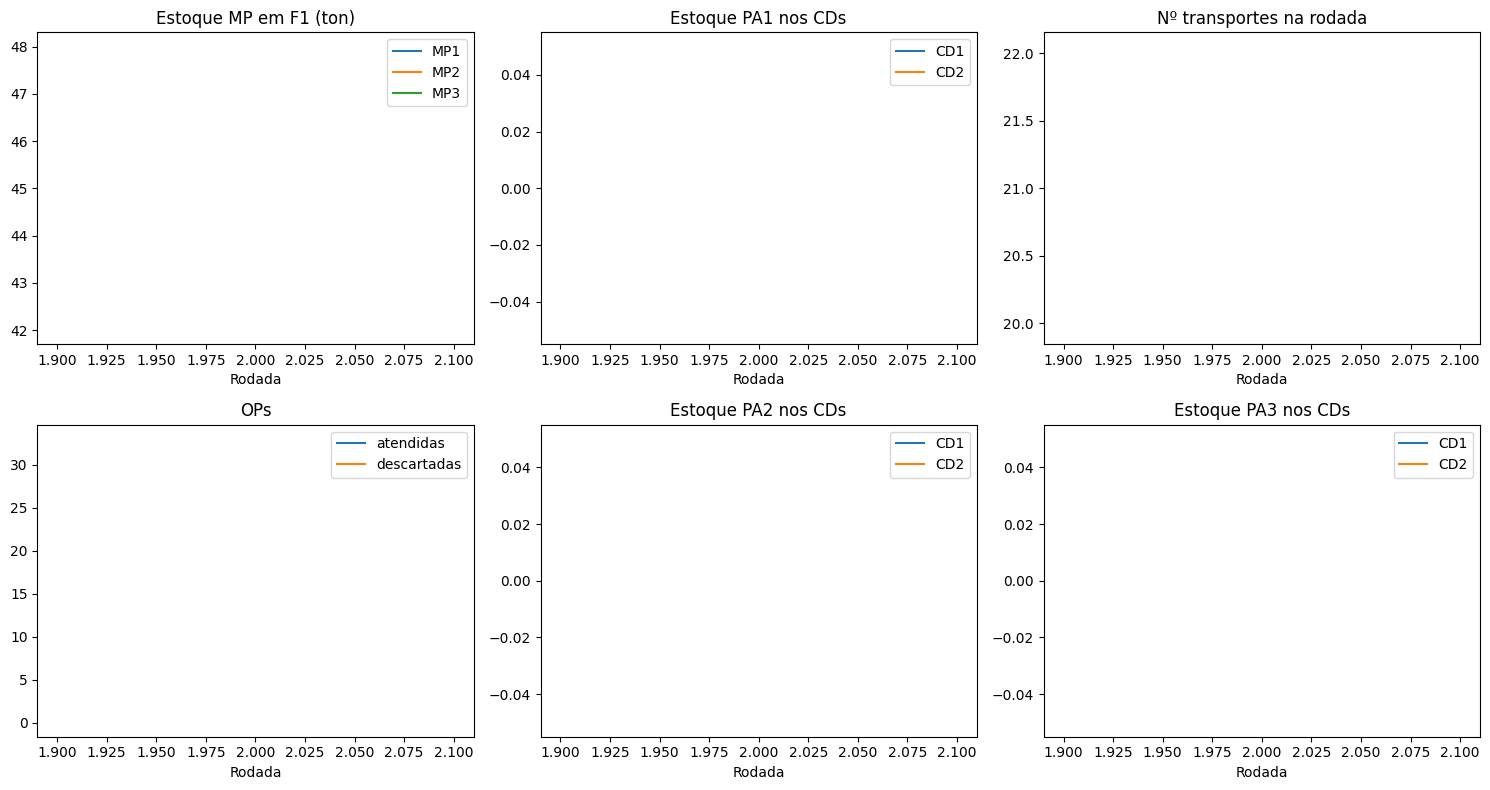

 rodada  transportes  ops_atendidas  ops_descartadas  estoque_mp1_F1  estoque_mp2_F1  estoque_mp3_F1  estoque_pa1_cd1  estoque_pa1_cd2  estoque_pa2_cd1  estoque_pa2_cd2  estoque_pa3_cd1  estoque_pa3_cd2
      2           21              0               33            47.0            48.0            42.0                0                0                0                0                0                0


In [13]:
plot_historico(BASE / 'estado')